In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import gzip
import shutil
import numpy as np
with gzip.open('data_3.4/RT.fits.gz', 'rb') as f_in:
    with open('data_3.4/RT.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
with gzip.open('data_th/Temperature.fits.gz', 'rb') as f_in:
    with open('data_th/Temperature.fits', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

Filename: data_3.4/RT.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (30, 30, 1, 1, 1)   float32   
  1                1 ImageHDU        10   (1, 1, 1, 2)   float32   
  2                1 ImageHDU         9   (1, 1, 1)   float32   
  3                1 ImageHDU         8   (3, 1)   float32   
1.3555099e-12


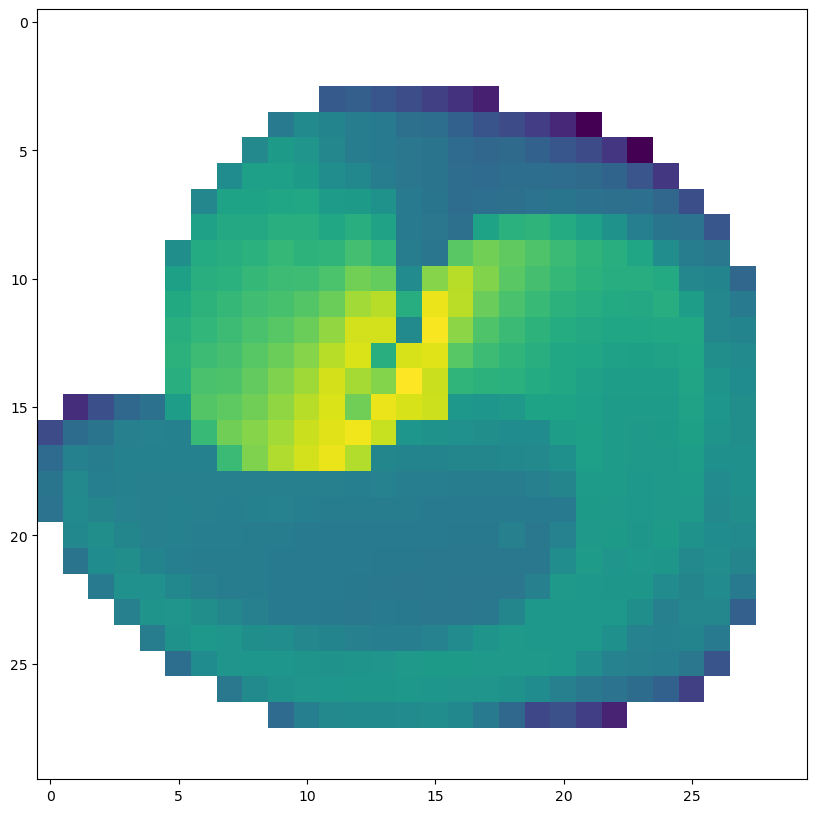

In [4]:
hdul = fits.open("data_3.4/RT.fits")
hdul.info()

data = hdul[0].data[0][0][0]

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(data[::-1, :], cmap='viridis', norm='log')

fig.savefig('image.png', dpi=400)

print(np.sum(data))

Filename: data_th/Temperature.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (8536,)   float32   


(array([  4.,   4.,  25.,  60., 104., 177., 247., 326., 418., 480., 411.,
        267., 187., 189., 214., 218., 199., 189., 163., 165., 162., 161.,
        173., 151., 161., 167., 152., 144., 153., 154., 138., 122., 126.,
        124., 113., 114., 101., 106.,  98.,  97.,  94.,  95.,  90.,  91.,
         78.,  84.,  85.,  68.,  82.,  76.,  61.,  64.,  68.,  66.,  53.,
         67.,  50.,  60.,  50.,  60.,  48.,  38.,  49.,  85.,  86.,  22.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([218.06958008, 220.44000244, 222.8104248 , 225.18083191,
        227.55125427, 229.92167664, 232.292099  , 234.66252136,
        237.03292847, 239.40335083, 241.77377319, 244.14419556,
        246.51461792, 248.88504028, 251.25546265, 253.62586975,
        255.99629211, 258.36669922, 260.73712158, 263.10754395

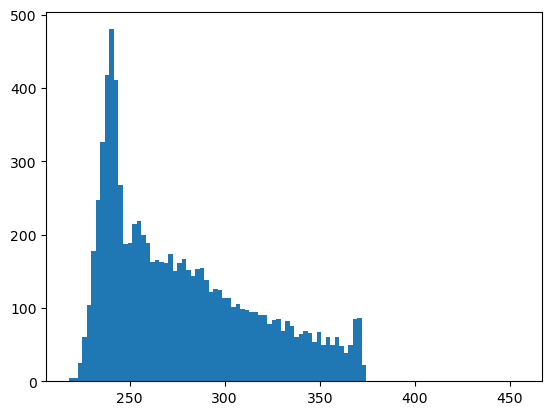

In [5]:

temps = fits.open("data_th/Temperature.fits")
temps.info()

temp_data = temps[0].data

fig, ax = plt.subplots()
ax.hist(temp_data, bins=100)

In [6]:
raw_densities = fits.open("apep1shell.fits")
raw_densities.info()

masses = raw_densities[0].data
weights = masses / max(masses)

particles = raw_densities[1].data
print(particles.shape)

Filename: apep1shell.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   (8537,)   float64   
  1                1 ImageHDU         7   (3, 8537)   float64   
(8537, 3)


/tmp/ipykernel_2003558/798996632.py:11: RuntimeWarning: invalid value encountered in divide
  H /= H_norm


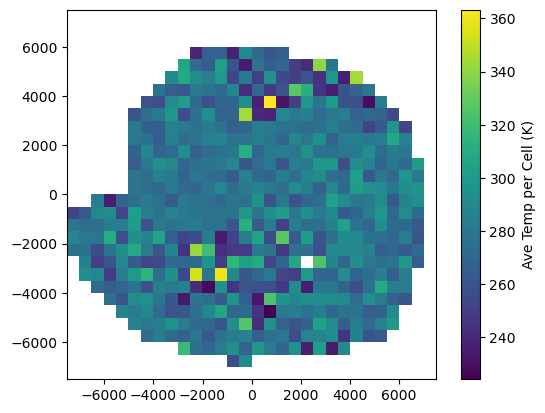

In [7]:
import numpy as np

resolution = hdul[0].data[0][0][0].shape[0]
indices = range(len(temp_data))
bound = np.max(np.abs(particles[indices, :2]))
pixels = np.linspace(-bound, bound, resolution + 1)

H, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels, weights=temp_data)
H_norm, x, y = np.histogram2d(particles[indices, 0], particles[indices, 1], bins=pixels)

H /= H_norm

fig, ax = plt.subplots()

# ax.scatter(particles[indices, 0], particles[indices, 1], c=temp_data, s=0.1)
# ax.set(aspect='equal')
p = ax.pcolormesh(x, y, H.T)
ax.set(aspect='equal')
fig.colorbar(p, label='Ave Temp per Cell (K)')

In [8]:
wcs

NameError: name 'wcs' is not defined